# 00. Prepare the Yelp Review Polarity Dataset (run this notebook first)

Downloads the **Yelp Review Polarity** benchmark (Zhang, Zhao & LeCun, NeurIPS 2015)
directly from the fast.ai AWS mirror - a plain HTTPS download, **no Hugging Face
account or token needed** - and saves three fixed splits to Google Drive so every
model notebook uses exactly the same data.

**Why this dataset next.** Our diagnosis across benchmarks is that BAMIC works best
with **many training documents of moderate length with strongly lexical sentiment** -
the IMDB profile, where it reached 0.865 accuracy with best-in-table calibration.
Yelp reviews match that profile even better (mean ~130 words, sentiment carried by
words like "delicious", "rude", "overpriced"), while ERASER movies (1,600 long
documents) sat below BAMIC's data floor.

**Splits.** The full benchmark has 560,000 train / 38,000 test reviews (balanced).
That is far more than we need and would multiply every Colab runtime, so we take a
**seeded, class-balanced subsample**: train 25,000 / valid 3,000 / test 10,000.
The sizes mirror the IMDB benchmark so runtimes and results are directly comparable,
and the fixed seed (20260526) makes the subsample fully reproducible.

**Label convention.** In the raw CSVs class 1 = negative, class 2 = positive
(Zhang et al.'s convention); we map them to y = 0 / 1.

**Cleaning.** Raw Yelp text contains literal `\n` escape sequences and escaped
quotes; we replace them with spaces / plain quotes and collapse whitespace.

**Outputs** (`AMIC project/yelp_benchmark/data/`): `yelp_train.csv`,
`yelp_valid.csv`, `yelp_test.csv`, each with columns `text` and `y` (1 = positive).

Run order: **00 -> 01 (BAMIC) -> 02 -> 03 -> 04 -> 05 -> 06.**

In [2]:
# ================================================================
# 0. Check the Colab GPU
# ================================================================

# Ask the Colab runtime which GPU we were given.
gpu_info = !nvidia-smi
# Join the command output lines into one printable string.
gpu_info = '\n'.join(gpu_info)
# If the command failed, we are not connected to a GPU runtime.
if gpu_info.find('failed') >= 0:
    print('Not connected to a GPU. In Colab: Runtime -> Change runtime type -> T4 GPU.')
else:
    print(gpu_info)

Mon Aug  3 22:27:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   36C    P0             57W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
# ================================================================
# 1. Check the Colab RAM
# ================================================================

# psutil reports how much system memory this runtime has.
import psutil
# Convert bytes to gigabytes for a readable number.
ram_gb = psutil.virtual_memory().total / 1e9
# Print the available RAM so we know which runtime type we received.
print('Your runtime has {:.1f} gigabytes of available RAM'.format(ram_gb))

Your runtime has 179.4 gigabytes of available RAM


In [4]:
# ================================================================
# 2. Basic imports and reproducibility (no Hugging Face account needed)
# ================================================================

# pathlib gives clean, operating-system-safe file paths.
from pathlib import Path

# random controls Python-level randomness.
import random

# re collapses whitespace during text cleaning.
import re

# tarfile unpacks the downloaded .tgz archive.
import tarfile

# requests downloads the dataset over plain HTTPS (no login, no token).
import requests

# numpy handles numeric arrays.
import numpy as np

# pandas handles CSV data tables.
import pandas as pd

# train_test_split creates a reproducible stratified holdout.
from sklearn.model_selection import train_test_split

# This seed keeps the subsample identical every time (same seed as all our notebooks).
SEED = 20260526

# Seed Python's random module.
random.seed(SEED)

# Seed NumPy's random generator.
np.random.seed(SEED)

In [6]:
# ================================================================
# 3. Mount Google Drive and define project paths
# ================================================================

# Mount Google Drive so Colab can read and write project files.
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted.')

# This is the same Google Drive project folder used by the wine and SST-2 notebooks.
PROJECT_DIR = Path('/content/drive/MyDrive/AMIC project')

# All Yelp benchmark files live inside this subfolder.
BENCH_DIR = PROJECT_DIR / 'yelp_benchmark'

# The shared, prepared Yelp splits are stored here by notebook 00.
DATA_DIR = BENCH_DIR / 'data'

# This notebook writes all of its results into its own output folder.
EXPERIMENT_NAME = 'yelp_data_prep'
OUTPUT_DIR = DATA_DIR  # the prepared CSVs ARE this notebook's output

# Create the output folder if it does not exist yet.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Print the paths so we can verify them before loading data.
print('DATA_DIR  :', DATA_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)

Mounted at /content/drive
Google Drive mounted.
DATA_DIR  : /content/drive/MyDrive/AMIC project/yelp_benchmark/data
OUTPUT_DIR: /content/drive/MyDrive/AMIC project/yelp_benchmark/data


In [7]:
# ================================================================
# 4. Download and extract the Yelp archive
# ================================================================

# The fast.ai AWS mirror of the official Zhang et al. (2015) release (about 166 MB).
YELP_URL = 'https://s3.amazonaws.com/fast-ai-nlp/yelp_review_polarity_csv.tgz'

# Where the archive and its extracted folder live on the Colab local disk.
ARCHIVE_PATH = Path('/content/yelp_review_polarity_csv.tgz')
EXTRACT_DIR = Path('/content')
YELP_DIR = EXTRACT_DIR / 'yelp_review_polarity_csv'

# Skip everything if the prepared CSVs already exist in Drive.
already_prepared = all((DATA_DIR / name).exists()
                       for name in ['yelp_train.csv', 'yelp_valid.csv', 'yelp_test.csv'])
print('Prepared CSVs already in Drive:', already_prepared)

if not already_prepared and not YELP_DIR.exists():
    # Stream the archive to disk in chunks so memory stays low.
    print('Downloading', YELP_URL, '(about 166 MB)...')
    with requests.get(YELP_URL, stream=True, timeout=600) as response:
        response.raise_for_status()
        with open(ARCHIVE_PATH, 'wb') as f:
            for chunk in response.iter_content(chunk_size=1 << 20):
                f.write(chunk)
    print('Download finished. Extracting...')
    # Extract train.csv / test.csv / readme.txt to local disk.
    with tarfile.open(ARCHIVE_PATH, 'r:gz') as tar:
        tar.extractall(EXTRACT_DIR)
    print('Extracted to', YELP_DIR)

Prepared CSVs already in Drive: False
Download finished. Extracting...


/tmp/ipykernel_7843/140302572.py:29: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(EXTRACT_DIR)


Extracted to /content/yelp_review_polarity_csv


In [8]:
# ================================================================
# 5. Read the raw CSVs and clean the text
# ================================================================

def clean_review(text):
    """Remove escaped line breaks / quotes and collapse whitespace."""
    # Guard against non-string values.
    if not isinstance(text, str):
        text = ''
    # The raw text stores line breaks as the two characters backslash + n.
    text = text.replace('\\n', ' ')
    # Escaped double quotes become plain quotes.
    text = text.replace('\\"', '"')
    # Collapse repeated whitespace into single spaces.
    return re.sub(r'\s+', ' ', text).strip()


if not already_prepared:
    # The CSVs have no header row: column 0 is the class, column 1 is the review text.
    raw_train = pd.read_csv(YELP_DIR / 'train.csv', header=None, names=['label', 'text'])
    raw_test = pd.read_csv(YELP_DIR / 'test.csv', header=None, names=['label', 'text'])
    # Map the Zhang et al. labels (1 = negative, 2 = positive) to y = 0 / 1.
    raw_train['y'] = (raw_train['label'] == 2).astype(int)
    raw_test['y'] = (raw_test['label'] == 2).astype(int)
    # Clean every review (560k rows - allow a minute or two).
    raw_train['text'] = raw_train['text'].map(clean_review)
    raw_test['text'] = raw_test['text'].map(clean_review)
    # Print the sizes and label balance as a sanity check.
    print('raw train:', raw_train.shape, '| positive rate:', raw_train['y'].mean())
    print('raw test :', raw_test.shape, '| positive rate:', raw_test['y'].mean())

raw train: (560000, 3) | positive rate: 0.5
raw test : (38000, 3) | positive rate: 0.5


In [10]:
# ================================================================
# 6. Seeded, class-balanced subsample -> our train/valid/test splits
# ================================================================

# Target sizes, chosen to mirror the IMDB benchmark (so Colab runtimes and
# model behavior are directly comparable across the two chapters).
N_TRAIN = 25000
N_VALID = 3000
N_TEST = 10000

if already_prepared:
    # The CSVs are already in Drive, so just load them back for the checks below.
    train_df = pd.read_csv(DATA_DIR / 'yelp_train.csv')
    valid_df = pd.read_csv(DATA_DIR / 'yelp_valid.csv')
    test_df = pd.read_csv(DATA_DIR / 'yelp_test.csv')
else:
    # Draw train+valid together from the official train pool, half per class,
    # then split off the validation part with stratification (keeps 50/50 balance
    # and guarantees train and valid never share a review).
    per_class = (N_TRAIN + N_VALID) // 2
    pool = pd.concat([
        raw_train[raw_train['y'] == 0].sample(per_class, random_state=SEED),
        raw_train[raw_train['y'] == 1].sample(per_class, random_state=SEED),
    ]).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    train_df, valid_df = train_test_split(
        pool, test_size=N_VALID, random_state=SEED, stratify=pool['y'])
    # The test subsample comes from the official TEST pool only (never from train).
    test_df = pd.concat([
        raw_test[raw_test['y'] == 0].sample(N_TEST // 2, random_state=SEED),
        raw_test[raw_test['y'] == 1].sample(N_TEST // 2, random_state=SEED),
    ]).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    # Keep only the two columns the model notebooks need, with clean row indices.
    train_df = train_df[['text', 'y']].reset_index(drop=True)
    valid_df = valid_df[['text', 'y']].reset_index(drop=True)
    test_df = test_df[['text', 'y']]

# Print the final sizes and label balance of each split.
# Expected: train (25000, 2), valid (3000, 2), test (10000, 2), positive rate 0.5.
print('train:', train_df.shape, '| positive rate:', round(train_df['y'].mean(), 4))
print('valid:', valid_df.shape, '| positive rate:', round(valid_df['y'].mean(), 4))
print('test :', test_df.shape, '| positive rate:', round(test_df['y'].mean(), 4))

train: (25000, 2) | positive rate: 0.5
valid: (3000, 2) | positive rate: 0.5
test : (10000, 2) | positive rate: 0.5


count    25000.000000
mean       134.158440
std        121.907628
min          1.000000
25%         52.000000
50%         99.000000
75%        176.000000
max        971.000000
Name: text, dtype: float64
Share of train reviews with <= 256 tokens: 0.875


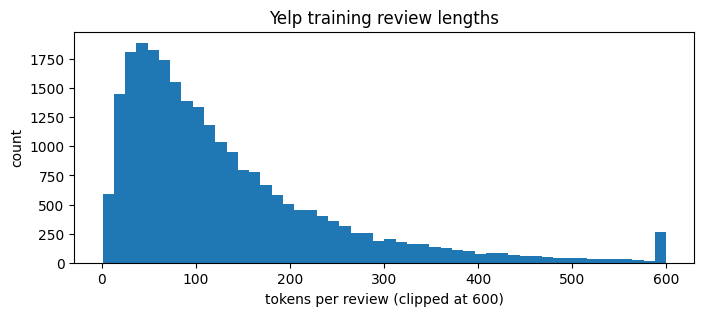

In [11]:
# ================================================================
# 7. Review lengths (informs MAX_LEN = 256 in the model notebooks)
# ================================================================

# matplotlib draws the histogram.
import matplotlib.pyplot as plt

# Count whitespace-separated tokens per training review.
lengths = train_df['text'].str.split().str.len()

# Print summary statistics of the length distribution.
print(lengths.describe())

# Print the share of reviews that fit within 256 tokens (expect roughly 0.88).
print('Share of train reviews with <= 256 tokens:', round((lengths <= 256).mean(), 4))

# Draw a simple histogram of review lengths (clipped at 600 for readability).
plt.figure(figsize=(8, 3))
plt.hist(lengths.clip(upper=600), bins=50)
plt.xlabel('tokens per review (clipped at 600)')
plt.ylabel('count')
plt.title('Yelp training review lengths')
plt.show()

In [12]:
# ================================================================
# 8. Save the shared splits to Drive
# ================================================================

# Every model notebook will read these three files, so we save them once here.
# (When the CSVs were already in Drive, this simply rewrites identical files.)
train_df.to_csv(DATA_DIR / 'yelp_train.csv', index=False)
valid_df.to_csv(DATA_DIR / 'yelp_valid.csv', index=False)
test_df.to_csv(DATA_DIR / 'yelp_test.csv', index=False)

# Confirm the files now exist in Drive.
for name in ['yelp_train.csv', 'yelp_valid.csv', 'yelp_test.csv']:
    path = DATA_DIR / name
    print(path, '| exists:', path.exists(), '| rows:', len(pd.read_csv(path)))

/content/drive/MyDrive/AMIC project/yelp_benchmark/data/yelp_train.csv | exists: True | rows: 25000
/content/drive/MyDrive/AMIC project/yelp_benchmark/data/yelp_valid.csv | exists: True | rows: 3000
/content/drive/MyDrive/AMIC project/yelp_benchmark/data/yelp_test.csv | exists: True | rows: 10000


**Done.** The three shared splits are saved. You can now run any model notebook (01-06).